# Predictive Maintenance: Engine Remaining Useful Life Prediction

**Course:** AI in Aviation — Day 1 Demo  
**Dataset:** NASA C-MAPSS FD001 (HPC degradation, sea-level conditions)  
**Objective:** Build a machine learning model that predicts how many operating cycles remain before an aircraft engine reaches failure, using sensor data.

**Prerequisite:** Install [`uv`](https://docs.astral.sh/uv/) once per machine.

```bash
# macOS / Linux
curl -LsSf https://astral.sh/uv/install.sh | sh

# Windows (PowerShell)
# powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"

# Verify
uv --version
```

**Set up the project environment** (run once per machine, from the project root):

```bash
# Initialize the uv project
uv init --python 3.11

# Add runtime dependencies
uv add pandas numpy scikit-learn matplotlib seaborn joblib

# Add notebook dependencies
uv add jupyterlab ipykernel ipython

# Register the kernel
uv run python -m ipykernel install --user --name ai_in_aviation --display-name "Python (ai_in_aviation)"
```

**Launch Jupyter:**

```bash
uv run jupyter lab
```

**Reproduce on another machine:**

```bash
uv sync
uv run jupyter lab
```

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Display utilities
from IPython.display import display, Image as IPythonImage

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.precision', 2)

# Matplotlib style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11


def show_image(image_path: str, width: int = 800):
    """Display an image (PNG, JPG, GIF) inline in the notebook."""
    display(IPythonImage(filename=image_path, width=width))

# Predictive Maintenance: Engine Remaining Useful Life Prediction

## Introduction

Aircraft engines are expensive, complex machines. A single turbofan engine can cost millions of dollars, and an unplanned failure can ground a flight, delay passengers, and create safety risks. Airlines need to know when an engine will fail so they can replace it during scheduled maintenance, not mid-flight.

**Remaining Useful Life (RUL)** is the number of operating cycles an engine can still run before it reaches a failure threshold. If we can predict RUL accurately, we can:

- Schedule maintenance before a failure occurs
- Avoid replacing a healthy engine too early
- Reduce downtime and operational costs

This approach is called **predictive maintenance**. Instead of fixing something on a fixed schedule or waiting for it to break, we use data to predict when it will need attention.

In this demo, we will use the NASA C-MAPSS dataset to build a machine learning model that predicts engine RUL from sensor data.

## About the C-MAPSS Dataset

The NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS) dataset provides simulated run-to-failure data for commercial turbofan engines. It is the standard benchmark for prognostics and health management research.

The dataset has four subsets (FD001–FD004), each with different operating conditions and fault modes. We use **FD001**, the simplest subset:

- **Operating condition:** Sea level (1 condition)
- **Fault mode:** HPC (High-Pressure Compressor) degradation (1 fault mode)
- **Training engines:** 100 (complete run-to-failure trajectories)
- **Test engines:** 100 (partial trajectories, we predict RUL for these)

Each row in the data represents a single operating cycle. Each engine has 26 measurements:

| Column | Description |
|---|---|
| 1 | Unit number (engine ID) |
| 2 | Time (cycle number) |
| 3–5 | Operational settings (3 values) |
| 6–26 | Sensor measurements (21 values) |

**Source:** Saxena, A., Goebel, K., Simon, D. and Eklund, N., "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation," in *Proc. 1st Int. Conf. on Prognostics and Health Management (PHM08)*, Denver, CO, Oct. 2008. [See `assets/cmapss/SOURCE.md` for license details.]

In [2]:
# Column names for the dataset
column_names = [
    'unit_number', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

# Load training data
train_path = '../assets/cmapss/train_FD001.txt'
train_raw = pd.read_csv(train_path, sep=r'\s+', engine='python', header=None, names=column_names)

print(f"Training data shape: {train_raw.shape[0]} rows x {train_raw.shape[1]} columns")
print(f"Number of unique engines: {train_raw['unit_number'].nunique()}")
train_raw.head()

Training data shape: 20631 rows x 26 columns
Number of unique engines: 100


,unit_number,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-7.00e-04,-4.00e-04,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.42,0.03,392,2388,100.0,39.06,23.42
1,1,2,1.90e-03,-3.00e-04,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.43,0.03,392,2388,100.0,39.00,23.42
2,1,3,-4.30e-03,3.00e-04,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.42,0.03,390,2388,100.0,38.95,23.34
3,1,4,7.00e-04,0.00e+00,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.37,0.03,392,2388,100.0,38.88,23.37
4,1,5,-1.90e-03,-2.00e-04,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.43,0.03,393,2388,100.0,38.90,23.40


## Looking at Individual Engines

Let's look at the first few cycles of three different engines to see how sensor readings vary:

- **Engine 1** — Early cycles of a healthy engine
- **Engine 39** — An engine with a short lifespan (degradation starts early)
- **Engine 69** — An engine with a long lifespan (stays healthy longer)

In [3]:
# Show first 5 cycles of three different engines
engines_to_show = [1, 39, 69]

for eng_id in engines_to_show:
    print(f"\n--- Engine {eng_id} (first 5 cycles) ---")
    display(train_raw[train_raw['unit_number'] == eng_id].head().style.hide(axis='index'))


--- Engine 1 (first 5 cycles) ---


unit_number,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
1,1,-0.000700,-0.000400,100.000000,518.670000,641.820000,1589.700000,1400.600000,14.620000,21.610000,554.360000,2388.060000,9046.190000,1.300000,47.470000,521.660000,2388.020000,8138.620000,8.419500,0.030000,392,2388,100.000000,39.060000,23.419000
1,2,0.001900,-0.000300,100.000000,518.670000,642.150000,1591.820000,1403.140000,14.620000,21.610000,553.750000,2388.040000,9044.070000,1.300000,47.490000,522.280000,2388.070000,8131.490000,8.431800,0.030000,392,2388,100.000000,39.000000,23.423600
1,3,-0.004300,0.000300,100.000000,518.670000,642.350000,1587.990000,1404.200000,14.620000,21.610000,554.260000,2388.080000,9052.940000,1.300000,47.270000,522.420000,2388.030000,8133.230000,8.417800,0.030000,390,2388,100.000000,38.950000,23.344200
1,4,0.000700,0.000000,100.000000,518.670000,642.350000,1582.790000,1401.870000,14.620000,21.610000,554.450000,2388.110000,9049.480000,1.300000,47.130000,522.860000,2388.080000,8133.830000,8.368200,0.030000,392,2388,100.000000,38.880000,23.373900
1,5,-0.001900,-0.000200,100.000000,518.670000,642.370000,1582.850000,1406.220000,14.620000,21.610000,554.000000,2388.060000,9055.150000,1.300000,47.280000,522.190000,2388.040000,8133.800000,8.429400,0.030000,393,2388,100.000000,38.900000,23.404400



--- Engine 39 (first 5 cycles) ---


unit_number,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
39,1,-0.000400,-0.000200,100.000000,518.670000,642.720000,1592.370000,1410.000000,14.620000,21.610000,552.820000,2388.120000,9043.490000,1.300000,47.640000,521.780000,2388.100000,8133.270000,8.445100,0.030000,392,2388,100.000000,38.900000,23.294700
39,2,-0.006200,0.000200,100.000000,518.670000,642.610000,1586.250000,1407.990000,14.620000,21.610000,553.250000,2388.100000,9049.070000,1.300000,47.600000,521.560000,2388.100000,8126.000000,8.427900,0.030000,395,2388,100.000000,38.820000,23.460400
39,3,0.000700,-0.000000,100.000000,518.670000,642.260000,1586.250000,1407.480000,14.620000,21.610000,552.900000,2388.130000,9040.050000,1.300000,47.560000,522.150000,2388.070000,8123.320000,8.414300,0.030000,394,2388,100.000000,38.730000,23.266900
39,4,-0.003900,0.000500,100.000000,518.670000,642.460000,1587.900000,1405.230000,14.620000,21.610000,553.550000,2388.120000,9053.540000,1.300000,47.400000,521.830000,2388.130000,8123.190000,8.459900,0.030000,394,2388,100.000000,38.820000,23.378900
39,5,0.003900,0.000200,100.000000,518.670000,642.310000,1587.080000,1408.780000,14.620000,21.610000,553.400000,2388.100000,9044.920000,1.300000,47.500000,521.760000,2388.070000,8125.880000,8.460700,0.030000,394,2388,100.000000,38.730000,23.333800



--- Engine 69 (first 5 cycles) ---


unit_number,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
69,1,-0.001400,-0.000100,100.000000,518.670000,641.960000,1587.100000,1400.650000,14.620000,21.610000,553.680000,2388.000000,9054.190000,1.300000,47.340000,522.030000,2388.030000,8136.880000,8.409400,0.030000,392,2388,100.000000,38.870000,23.408100
69,2,-0.000300,-0.000400,100.000000,518.670000,641.500000,1594.240000,1401.540000,14.620000,21.610000,554.220000,2388.040000,9057.570000,1.300000,47.260000,522.080000,2388.080000,8139.880000,8.417200,0.030000,392,2388,100.000000,39.020000,23.418900
69,3,0.000600,-0.000300,100.000000,518.670000,642.730000,1585.410000,1405.220000,14.620000,21.610000,554.110000,2388.040000,9052.770000,1.300000,47.350000,522.050000,2388.060000,8136.420000,8.386900,0.030000,392,2388,100.000000,38.820000,23.375600
69,4,-0.000100,-0.000300,100.000000,518.670000,642.000000,1586.570000,1408.440000,14.620000,21.610000,553.840000,2388.030000,9061.890000,1.300000,47.350000,521.630000,2388.050000,8142.920000,8.389000,0.030000,391,2388,100.000000,38.990000,23.274400
69,5,0.002600,0.000200,100.000000,518.670000,642.370000,1582.600000,1403.070000,14.620000,21.610000,554.000000,2388.060000,9064.650000,1.300000,47.340000,522.310000,2388.070000,8138.930000,8.404200,0.030000,392,2388,100.000000,38.870000,23.319500


## The 21 Engine Sensors

Each engine is monitored by 21 sensors measuring temperatures, pressures, speeds, and derived ratios. Here is what each sensor represents:,

| Sensor | Symbol | Description |
|--------|--------|-------------|
| 1 | T2 | Total temperature at fan inlet (°R) |
| 2 | T24 | Total temperature at LPC outlet (°R) |
| 3 | T30 | Total temperature at HPC outlet (°R) |
| 4 | T50 | Total temperature at LPT outlet (°R) |
| 5 | P2 | Pressure at fan inlet (psia) |
| 6 | P15 | Total pressure in bypass duct (psia) |
| 7 | P30 | Total pressure at HPC outlet (psia) |
| 8 | Nf | Physical fan speed (rpm) |
| 9 | Nc | Physical core speed (rpm) |
| 10 | epr | Engine pressure ratio (P50/P2) |
| 11 | Ps30 | Static pressure at HPC outlet (psia) |
| 12 | phi | Ratio of fuel flow to Ps30 (pps/psi) |
| 13 | NRf | Corrected fan speed (rpm) |
| 14 | NRc | Corrected core speed (rpm) |
| 15 | BPR | Bypass ratio |
| 16 | farB | Burner fuel-air ratio |
| 17 | htBleed | Bleed enthalpy |
| 18 | Nf_dmd | Demanded fan speed (rpm) |
| 19 | PCNfR_dmd | Demanded corrected fan speed (rpm) |
| 20 | W31 | HPT coolant bleed (lbm/s) |
| 21 | W32 | LPT coolant bleed (lbm/s) |

These sensors span the entire engine — from the fan inlet (front) through the compressor, combustor, and turbine (rear). By monitoring all of them together, we can detect degradation patterns that no single sensor could reveal alone.

**Reference:** Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). \"Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation.\" *Proceedings of the 1st International Conference on Prognostics and Health Management (PHM08)*, Denver, CO. NASA Ames Research Center."

## Data as Matrices and Vectors

In the lecture, we discussed how data can be represented mathematically. This training table is a perfect example:

- The entire table is a **matrix** $\mathbf{X} \in \mathbb{R}^{m \times n}$ with $m$ rows (observations) and $n$ columns (features).
- Each row is a **row vector** representing one measurement at one cycle.
- Each column is a **column vector** representing one variable across all cycles.
- A single cell value is a **scalar**.

For our training data:

- Matrix $\mathbf{X}$ has shape (20,631 x 26) — over 20,000 measurements across 26 variables.
- Each engine contributes multiple rows (one per cycle).
- Our goal: learn a function $f$ that maps sensor readings to RUL, so $\hat{y} = f(\mathbf{x})$.

In [4]:
# Load test data
test_path = '../assets/cmapss/test_FD001.txt'
test_raw = pd.read_csv(test_path, sep=r'\s+', engine='python', header=None, names=column_names)

# Load RUL ground truth
rul_path = '../assets/cmapss/RUL_FD001.txt'
rul_raw = pd.read_csv(rul_path, sep=r'\s+', engine='python', header=None, names=['rul', 'threshold'])

print(f"Test data shape: {test_raw.shape[0]} rows x {test_raw.shape[1]} columns")
print(f"Number of unique test engines: {test_raw['unit_number'].nunique()}")
print(f"RUL data shape: {rul_raw.shape[0]} engines")
print(f"\nRUL statistics:")
print(rul_raw['rul'].describe())

Test data shape: 13096 rows x 26 columns
Number of unique test engines: 100
RUL data shape: 100 engines

RUL statistics:
count    100.00
mean      75.52
std       41.76
min        7.00
25%       32.75
50%       86.00
75%      112.25
max      145.00
Name: rul, dtype: float64


## Exploratory Data Analysis

Before building a model, we look at the data to understand patterns. We will examine sensor readings over time for a few engines and the distribution of RUL values.

Engine health monitoring works like a doctor checking vital signs. Each sensor is a different vital sign. When an engine is healthy, the readings stay stable. As degradation sets in, the readings drift. Our job is to spot that drift and estimate how much time is left.

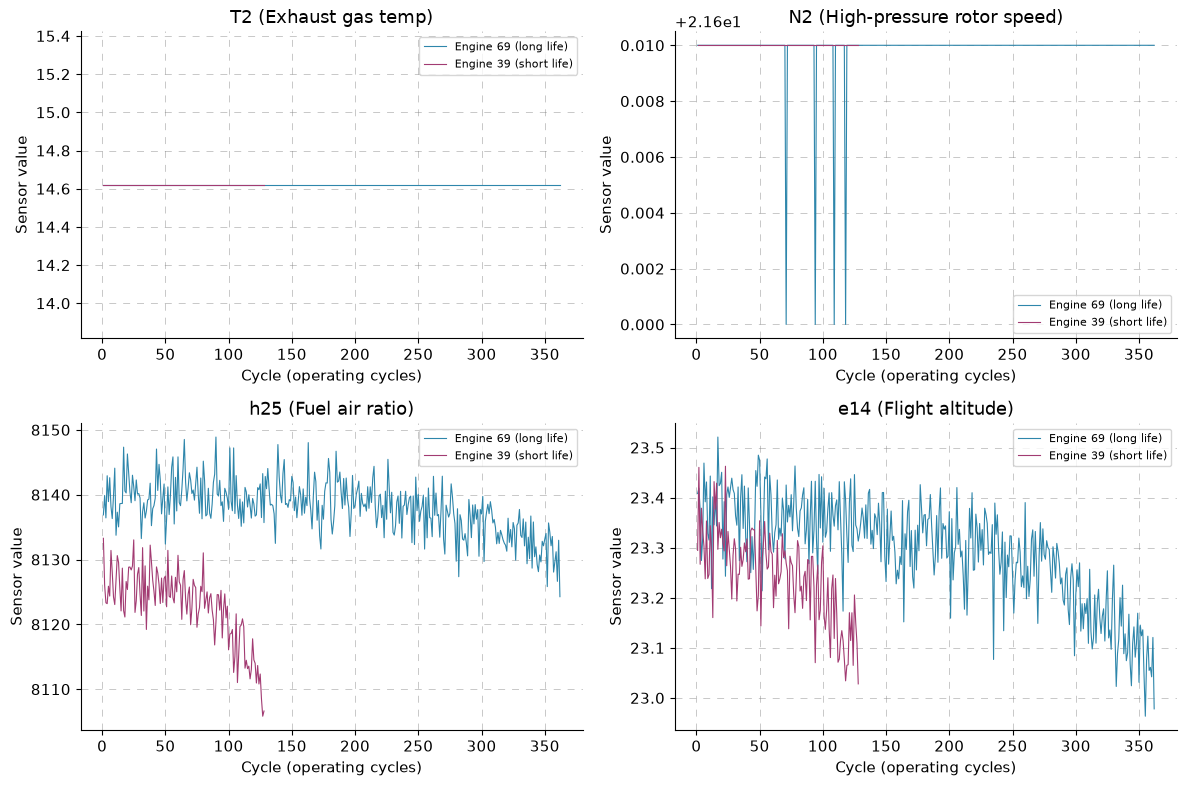

In [5]:
# Pick two engines: one with long life, one with short life
engine_ids = sorted(train_raw['unit_number'].unique())
engine_cycles = train_raw.groupby('unit_number')['cycle'].max()
long_engine = engine_cycles.nlargest(1).index[0]
short_engine = engine_cycles.nsmallest(1).index[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sensors_to_plot = ['sensor_5', 'sensor_6', 'sensor_14', 'sensor_21']
titles = ['T2 (Exhaust gas temp)', 'N2 (High-pressure rotor speed)',
          'h25 (Fuel air ratio)', 'e14 (Flight altitude)']

for idx, (sensor, title) in enumerate(zip(sensors_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]
    for eng_id, color, label in [(long_engine, '#2E86AB', f'Engine {long_engine} (long life)'),
                                  (short_engine, '#A23B72', f'Engine {short_engine} (short life)')]:
        eng_data = train_raw[train_raw['unit_number'] == eng_id]
        ax.plot(eng_data['cycle'], eng_data[sensor], color=color, label=label, linewidth=0.8)
    ax.set_xlabel('Cycle (operating cycles)')
    ax.set_ylabel('Sensor value')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('../assets/sensor_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** Sensor trajectories for two engines with different lifespans. The engine with shorter life (purple) shows faster drift in sensor values compared to the longer-lived engine (blue). Notice how sensor readings gradually change as the engine degrades. This drift is what our model learns to detect.

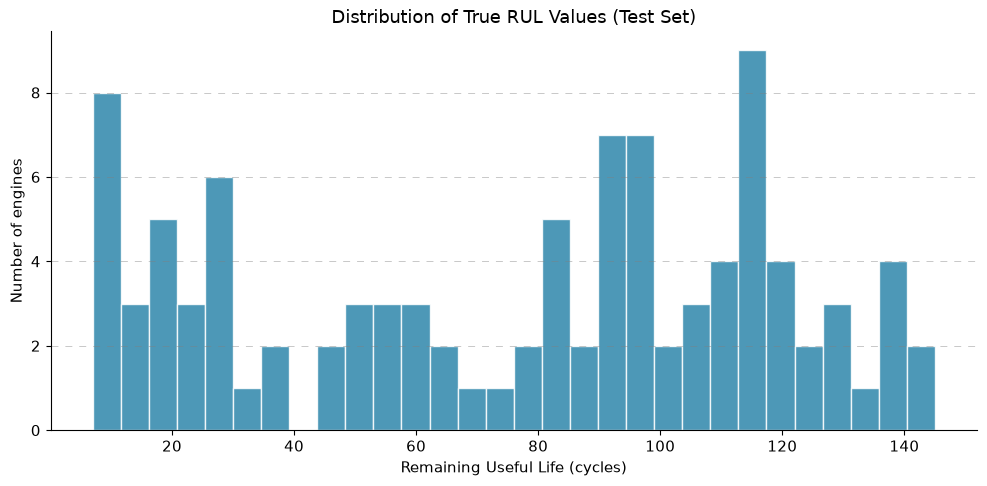

In [6]:
# RUL distribution histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rul_raw['rul'], bins=30, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set_xlabel('Remaining Useful Life (cycles)')
ax.set_ylabel('Number of engines')
ax.set_title('Distribution of True RUL Values (Test Set)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6, axis='y')
plt.tight_layout()
plt.savefig('../assets/rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** Distribution of true RUL values across the 100 test engines. Most engines have between 0 and 50 remaining cycles, with a few outliers. This distribution tells us what range our model needs to predict.

## Dimensionality Reduction with PCA

We have 21 sensors — too many to visualize at once. **Principal Component Analysis (PCA)** compresses these into 2 dimensions while preserving the most important patterns.

PCA works by finding the directions of maximum variance in the data. The first principal component (PC1) captures the most variation, and the second (PC2) captures the next most, orthogonal to the first.

We will apply PCA to the last-cycle sensor readings of each test engine, colored by their RUL. If healthy engines cluster separately from failing ones, it means the sensor data contains useful information for prediction.

PCA explained variance: PC1=57.1%, PC2=15.9%
Total variance captured in 2D: 73.0%


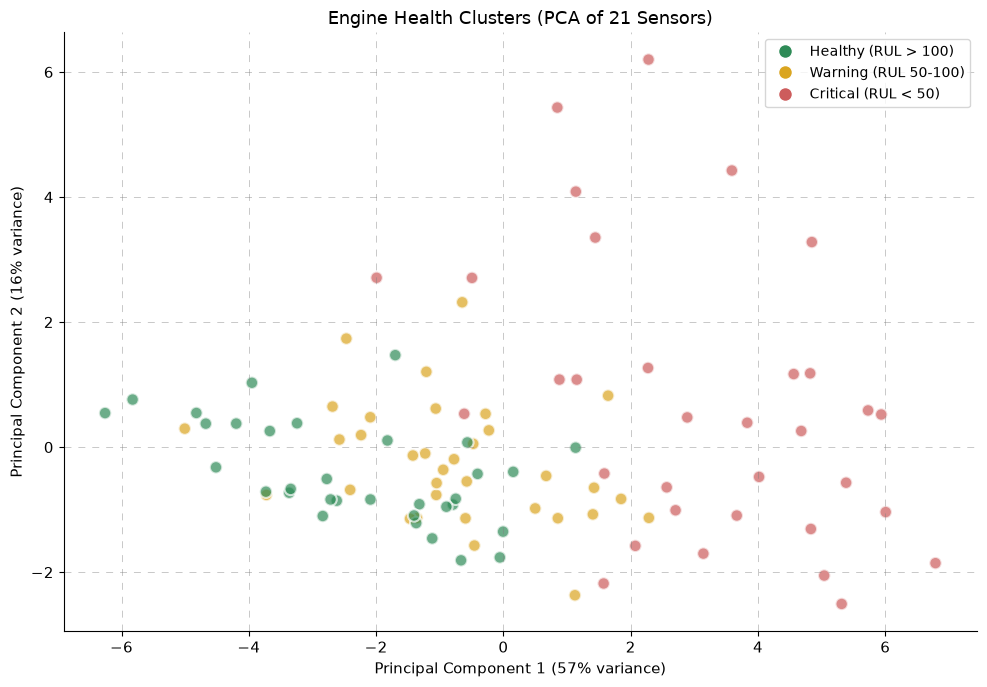

In [7]:
# Extract last-cycle sensor readings for each test engine
sensor_cols = [c for c in test_raw.columns if c.startswith('sensor_')]
test_last_cycle = test_raw.groupby('unit_number').last().reset_index().sort_values('unit_number')
X_sensors = test_last_cycle[sensor_cols].values
y_rul = rul_raw['rul'].values

# Scale sensor data
pca_scaler = StandardScaler()
X_scaled = pca_scaler.fit_transform(X_sensors)

# Apply PCA: reduce 21 sensors to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

# Color by health state
def health_color(rul):
    if rul > 100:
        return '#2E8B57'  # Sea green — healthy
    elif rul > 50:
        return '#DAA520'  # Goldenrod — warning
    else:
        return '#CD5C5C'  # Indian red — critical

colors = [health_color(r) for r in y_rul]

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=80, alpha=0.7,
                      edgecolors='white', linewidth=1.5)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E8B57', markersize=10, label='Healthy (RUL > 100)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#DAA520', markersize=10, label='Warning (RUL 50-100)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#CD5C5C', markersize=10, label='Critical (RUL < 50)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='best')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
ax.set_title('Engine Health Clusters (PCA of 21 Sensors)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig('../assets/pca_engine_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** PCA visualization of test engines colored by health state. Green dots are healthy engines (RUL > 100), yellow are in warning zone (50-100), and red are critical (< 50). If the clusters are somewhat separated, it means sensor data contains information that a model can learn from.

## Preprocessing and Feature Engineering

Raw sensor data is noisy and changes from cycle to cycle. We need to extract meaningful features that capture the *trend* of degradation, not just the instantaneous reading.

We use a **sliding window** approach: for each engine, we look at the last $N$ cycles and compute statistics (mean, standard deviation, minimum, maximum) for each sensor. This smooths out noise and captures the recent trend.

The window size $N$ is a hyperparameter. We will try three values (15, 25, 50 cycles) and pick the one that gives the best result. This is a standard step in machine learning called **hyperparameter tuning**.

The cell below shows a visual example of how one raw sensor reading becomes four engineered features through the sliding window process.

In [8]:
def extract_features(df, window_size):
    """Extract sliding window features from raw sensor data.
    
    For each cycle of each engine, compute rolling statistics over the 
    previous window_size cycles. Returns one row per cycle.
    
    Args:
        df: DataFrame with raw sensor data.
        window_size: Number of cycles to look back for rolling statistics.
    
    Returns:
        DataFrame with extracted features, one row per cycle.
    """
    sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
    feature_frames = []
    
    for unit_id, group in df.groupby('unit_number'):
        group = group.sort_values('cycle').copy()
        # Compute rolling statistics over the last window_size cycles
        rolling = group[sensor_cols].rolling(window=window_size, min_periods=1)
        roll_mean = rolling.mean()
        roll_std = rolling.std().fillna(0)
        roll_min = rolling.min()
        roll_max = rolling.max()
        
        # Build feature DataFrame for this engine
        features = pd.DataFrame()
        for col in sensor_cols:
            features[f'{col}_mean'] = roll_mean[col].values
            features[f'{col}_std'] = roll_std[col].values
            features[f'{col}_min'] = roll_min[col].values
            features[f'{col}_max'] = roll_max[col].values
        
        # Keep unit_number and cycle for RUL computation
        features['unit_number'] = group['unit_number'].values
        features['cycle'] = group['cycle'].values
        feature_frames.append(features)
    
    return pd.concat(feature_frames, ignore_index=True)

# Extract features for training data with different window sizes
window_sizes = [15, 25, 50]
print("Extracting features for different window sizes...")

train_features = {}
for ws in window_sizes:
    train_features[ws] = extract_features(train_raw, ws)
    print(f"  Window {ws}: {train_features[ws].shape[1] - 2} features, {train_features[ws].shape[0]} cycles")

Extracting features for different window sizes...
  Window 15: 84 features, 20631 cycles
  Window 25: 84 features, 20631 cycles
  Window 50: 84 features, 20631 cycles


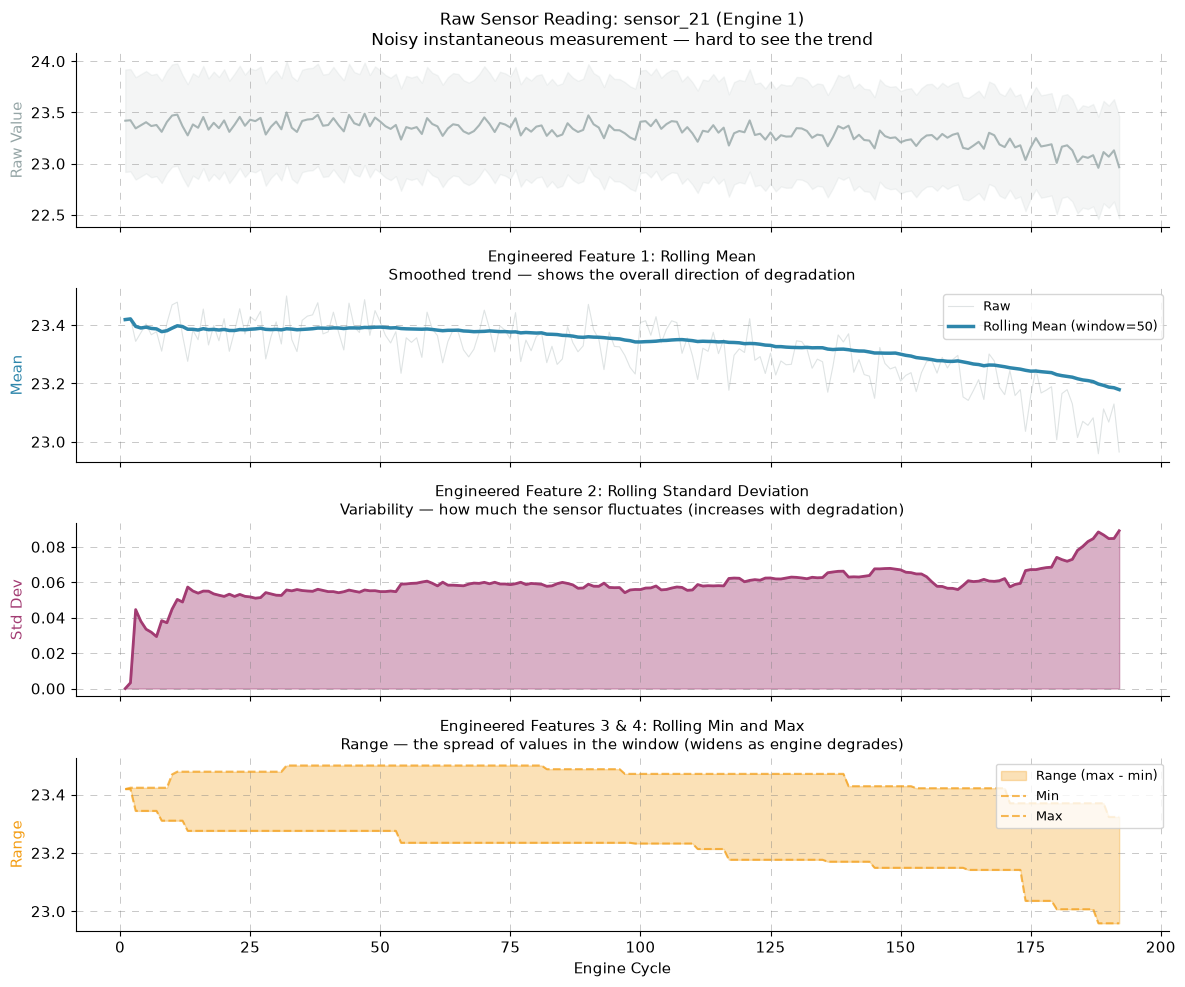

In [18]:
# Visualize the feature engineering process using one sensor from one engine
# This shows how raw sensor data becomes 4 engineered features

sensor_to_show = 'sensor_21'  # h21 — compressor outlet enthalpy (shows clear degradation)
engine_to_show = 1
window_demo = 50

eng_data = train_raw[train_raw['unit_number'] == engine_to_show].sort_values('cycle').copy()
cycles = eng_data['cycle'].values
raw_values = eng_data[sensor_to_show].values

# Compute rolling statistics
rolling = eng_data[sensor_to_show].rolling(window=window_demo, min_periods=1)
feat_mean = rolling.mean().values
feat_std = rolling.std().fillna(0).values
feat_min = rolling.min().values
feat_max = rolling.max().values

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Color palette
raw_color = '#95A5A6'
mean_color = '#2E86AB'
std_color = '#A23B72'
range_color = '#F39C12'

# Panel 1: Raw sensor reading
ax = axes[0]
ax.plot(cycles, raw_values, color=raw_color, linewidth=1.5, alpha=0.8)
ax.fill_between(cycles, raw_values - 0.5, raw_values + 0.5, color=raw_color, alpha=0.1)
ax.set_ylabel('Raw Value', fontsize=11, color=raw_color)
ax.set_title(f'Raw Sensor Reading: {sensor_to_show} (Engine {engine_to_show})\nNoisy instantaneous measurement — hard to see the trend', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)

# Panel 2: Rolling mean (smoothed trend)
ax = axes[1]
ax.plot(cycles, raw_values, color=raw_color, linewidth=0.8, alpha=0.3, label='Raw')
ax.plot(cycles, feat_mean, color=mean_color, linewidth=2.5, label=f'Rolling Mean (window={window_demo})')
ax.set_ylabel('Mean', fontsize=11, color=mean_color)
ax.set_title('Engineered Feature 1: Rolling Mean\nSmoothed trend — shows the overall direction of degradation', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)

# Panel 3: Rolling std (variability)
ax = axes[2]
ax.fill_between(cycles, 0, feat_std, color=std_color, alpha=0.4)
ax.plot(cycles, feat_std, color=std_color, linewidth=2)
ax.set_ylabel('Std Dev', fontsize=11, color=std_color)
ax.set_title('Engineered Feature 2: Rolling Standard Deviation\nVariability — how much the sensor fluctuates (increases with degradation)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)

# Panel 4: Rolling range (max - min)
ax = axes[3]
ax.fill_between(cycles, feat_min, feat_max, color=range_color, alpha=0.3, label='Range (max - min)')
ax.plot(cycles, feat_min, color=range_color, linewidth=1.5, linestyle='--', alpha=0.7, label='Min')
ax.plot(cycles, feat_max, color=range_color, linewidth=1.5, linestyle='--', alpha=0.7, label='Max')
ax.set_ylabel('Range', fontsize=11, color=range_color)
ax.set_xlabel('Engine Cycle', fontsize=11)
ax.set_title('Engineered Features 3 & 4: Rolling Min and Max\nRange — the spread of values in the window (widens as engine degrades)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('../assets/feature_engineering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** How one raw sensor becomes four engineered features. The top panel shows the noisy raw reading — it's hard to tell if the engine is degrading. The second panel shows the rolling mean, which smooths out the noise and reveals the downward trend. The third panel shows variability (standard deviation), which increases as the engine becomes less stable. The bottom panel shows the range (min to max), which widens as degradation progresses.

With 21 sensors × 4 statistics = **84 features**, our model has a rich description of engine health at every cycle.

In [9]:
# Create RUL labels for training data
# RUL at cycle t = max_cycle_for_engine - t
max_cycles_per_engine = train_raw.groupby('unit_number')['cycle'].max().to_dict()

# Split training data into train/validation for hyperparameter tuning
from sklearn.model_selection import train_test_split

results = []

for ws in window_sizes:
    feat = train_features[ws].copy()
    # Compute RUL for each cycle
    feat['rul'] = feat.apply(lambda row: max_cycles_per_engine[row['unit_number']] - row['cycle'], axis=1)
    
    # Only use cycles where RUL <= 125 (standard C-MAPSS threshold)
    feat = feat[feat['rul'] <= 125].copy()
    
    # Separate features and labels
    feature_cols = [c for c in feat.columns if c not in ['unit_number', 'cycle', 'rul']]
    X = feat[feature_cols].values
    y = feat['rul'].values
    
    # Split 80/20 for validation
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Normalize features
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    
    # Quick GBR model for comparison
    model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
    model.fit(X_tr_scaled, y_tr)
    y_pred = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    results.append({'window_size': ws, 'validation_rmse': round(rmse, 2)})
    print(f"Window size {ws}: Validation RMSE = {rmse:.2f} (trained on {len(X_tr)} samples)")

# Show comparison table
results_df = pd.DataFrame(results)
best_ws = results_df.loc[results_df['validation_rmse'].idxmin(), 'window_size']
print(f"\nBest window size: {best_ws} (lowest validation RMSE)")
results_df

Window size 15: Validation RMSE = 11.48 (trained on 10080 samples)
Window size 25: Validation RMSE = 9.75 (trained on 10080 samples)
Window size 50: Validation RMSE = 7.24 (trained on 10080 samples)

Best window size: 50 (lowest validation RMSE)


,window_size,validation_rmse
0,15,11.48
1,25,9.75
2,50,7.24


The table above shows how window size affects model accuracy. A smaller window captures recent changes but may be noisy. A larger window smooths more but may miss fast degradation. We pick the window size with the lowest validation RMSE and use it for the final model.

In [10]:
# Use the best window size for final feature extraction
feat_train = train_features[best_ws].copy()
feat_train['rul'] = feat_train.apply(lambda row: max_cycles_per_engine[row['unit_number']] - row['cycle'], axis=1)
feat_train = feat_train[feat_train['rul'] <= 125].copy()

feature_cols = [c for c in feat_train.columns if c not in ['unit_number', 'cycle', 'rul']]
X_train = feat_train[feature_cols].values
y_train = feat_train['rul'].values

# Extract test features (last cycle per engine only)
test_feat_all = extract_features(test_raw, best_ws)
# For test set, take only the last cycle of each engine, sorted by unit_number
test_last = test_feat_all.groupby('unit_number').last().reset_index().sort_values('unit_number')
X_test = test_last[feature_cols].values

# Normalize features (fit on training data only, then transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features: {X_train_scaled.shape}")
print(f"Test features: {X_test_scaled.shape}")
print(f"Features are normalized (mean ~0, std ~1):")
print(f"  Training mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

Training features: (12600, 84)
Test features: (100, 84)
Features are normalized (mean ~0, std ~1):
  Training mean: -0.0000, std: 0.8381


## Model Training

We will train four models and compare them, from simple to complex:

1. **Linear Regression** — fits a straight line (hyperplane) through the data. Fast and interpretable, but can only capture linear relationships. Think of it as drawing the best straight line through a scatter plot.

2. **Support Vector Regression (SVR)** — finds a "tube" around the data that minimizes errors. It can capture non-linear patterns using a technique called the "kernel trick." More flexible than linear regression but slower to train.

3. **Gradient Boosting Regressor** — builds decision trees sequentially, where each new tree corrects the errors of the previous ones. Think of it as a team of experts, each one focusing on what the last one got wrong.

4. **Random Forest Regressor** — builds many decision trees independently on random subsets of data, then averages their predictions. Think of it as asking many experts for their opinion and taking the average.

Models 3 and 4 are **tree-based ensemble methods**. They work well on tabular data, handle non-linear relationships, and do not require GPU acceleration. We compare all four to see how model complexity affects prediction quality.

In [11]:
# Train all four models
import time

models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf', C=100, gamma='scale'),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=42, n_jobs=-1
    )
}

trained_models = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    print(f"{name}: trained in {elapsed:.1f}s")

Linear Regression: trained in 0.0s
SVR: trained in 10.1s
Gradient Boosting: trained in 18.6s
Random Forest: trained in 5.6s


## Model Evaluation

We evaluate both models on the test set using two metrics:

1. **RMSE (Root Mean Square Error)** — the average prediction error in cycles. Lower is better. An RMSE of 10 means our predictions are off by about 10 cycles on average.

2. **PHM Score** — the standard metric from the PHM 2008/2009 Data Challenge. It uses an asymmetric penalty: under-predicting RUL (predicting failure sooner than it happens) is safer for maintenance, so it gets a smaller penalty. Over-predicting (missing a failure) is dangerous, so it gets a heavier penalty.

PHM Score formula:
- For each engine: $err = \hat{RUL} - RUL_{true}$
- If $err < 0$ (under-prediction): $score = \exp(-err / 13) - 1$
- If $err \geq 0$ (over-prediction): $score = \exp(err / 10) - 1$
- Total score = sum across all test engines. Lower (more negative) is better.

In [12]:
def compute_phm_score(y_true, y_pred):
    """Compute PHM score using the standard exponential penalty formula.
    
    Under-prediction (safer): exp(-err/13) - 1
    Over-prediction (dangerous): exp(err/10) - 1
    Lower (more negative) is better.
    """
    err = y_pred - y_true
    score = np.zeros_like(err, dtype=float)
    # Under-prediction (err < 0)
    neg_mask = err < 0
    score[neg_mask] = np.exp(-err[neg_mask] / 13.0) - 1
    # Over-prediction (err >= 0)
    pos_mask = err >= 0
    score[pos_mask] = np.exp(err[pos_mask] / 10.0) - 1
    return np.sum(score)

# Get true RUL values (for the last cycle of each test engine)
y_test = rul_raw['rul'].values

# Evaluate all four models
results = []
predictions = {}

print("=" * 55)
print("MODEL EVALUATION RESULTS (C-MAPSS FD001 Test Set)")
print("=" * 55)

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    phm = compute_phm_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': round(rmse, 2), 'PHM Score': round(phm, 2)})
    print(f"\n{name}:")
    print(f"  RMSE:      {rmse:.2f}")
    print(f"  PHM Score: {phm:.2f}")

print(f"\n{'=' * 55}")

# Comparison table
comparison = pd.DataFrame(results)
comparison = comparison.sort_values('RMSE').reset_index(drop=True)
best_model_name = comparison.iloc[0]['Model']
print(f"\nBest model: {best_model_name} (lowest RMSE)")
comparison

MODEL EVALUATION RESULTS (C-MAPSS FD001 Test Set)

Linear Regression:
  RMSE:      22.71
  PHM Score: 857.51

SVR:
  RMSE:      20.64
  PHM Score: 687.68

Gradient Boosting:
  RMSE:      19.10
  PHM Score: 630.70

Random Forest:
  RMSE:      20.31
  PHM Score: 721.22


Best model: Gradient Boosting (lowest RMSE)


,Model,RMSE,PHM Score
0,Gradient Boosting,19.10,630.70
1,Random Forest,20.31,721.22
2,SVR,20.64,687.68
3,Linear Regression,22.71,857.51


The table above shows how model complexity affects prediction quality. Linear Regression is the simplest but struggles with non-linear sensor patterns. SVR handles non-linearity but is slower. The ensemble methods (Gradient Boosting and Random Forest) typically achieve the best results on tabular data. We pick the model with the lowest RMSE for deployment.

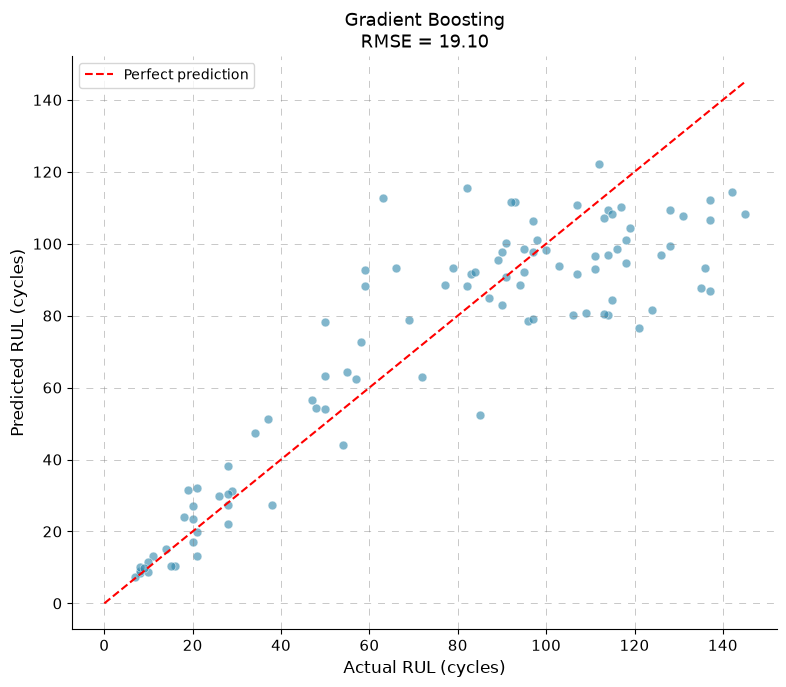

In [13]:
# Predicted vs Actual RUL scatter plot for the best model
best_model_name = comparison.iloc[0]['Model']
y_pred_best = predictions[best_model_name]
best_rmse = comparison.iloc[0]['RMSE']

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred_best, color='#2E86AB', alpha=0.6, s=40, edgecolors='white', linewidth=0.5)
# Perfect prediction line
max_rul = max(y_test.max(), y_pred_best.max())
ax.plot([0, max_rul], [0, max_rul], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax.set_title(f'{best_model_name}\nRMSE = {best_rmse:.2f}', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig('../assets/predicted_vs_actual_rul.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** Predicted vs actual RUL for the best-performing model. Points closer to the red dashed line (perfect prediction) indicate more accurate predictions. The model captures the general trend, with some scatter expected given the complexity of engine degradation.

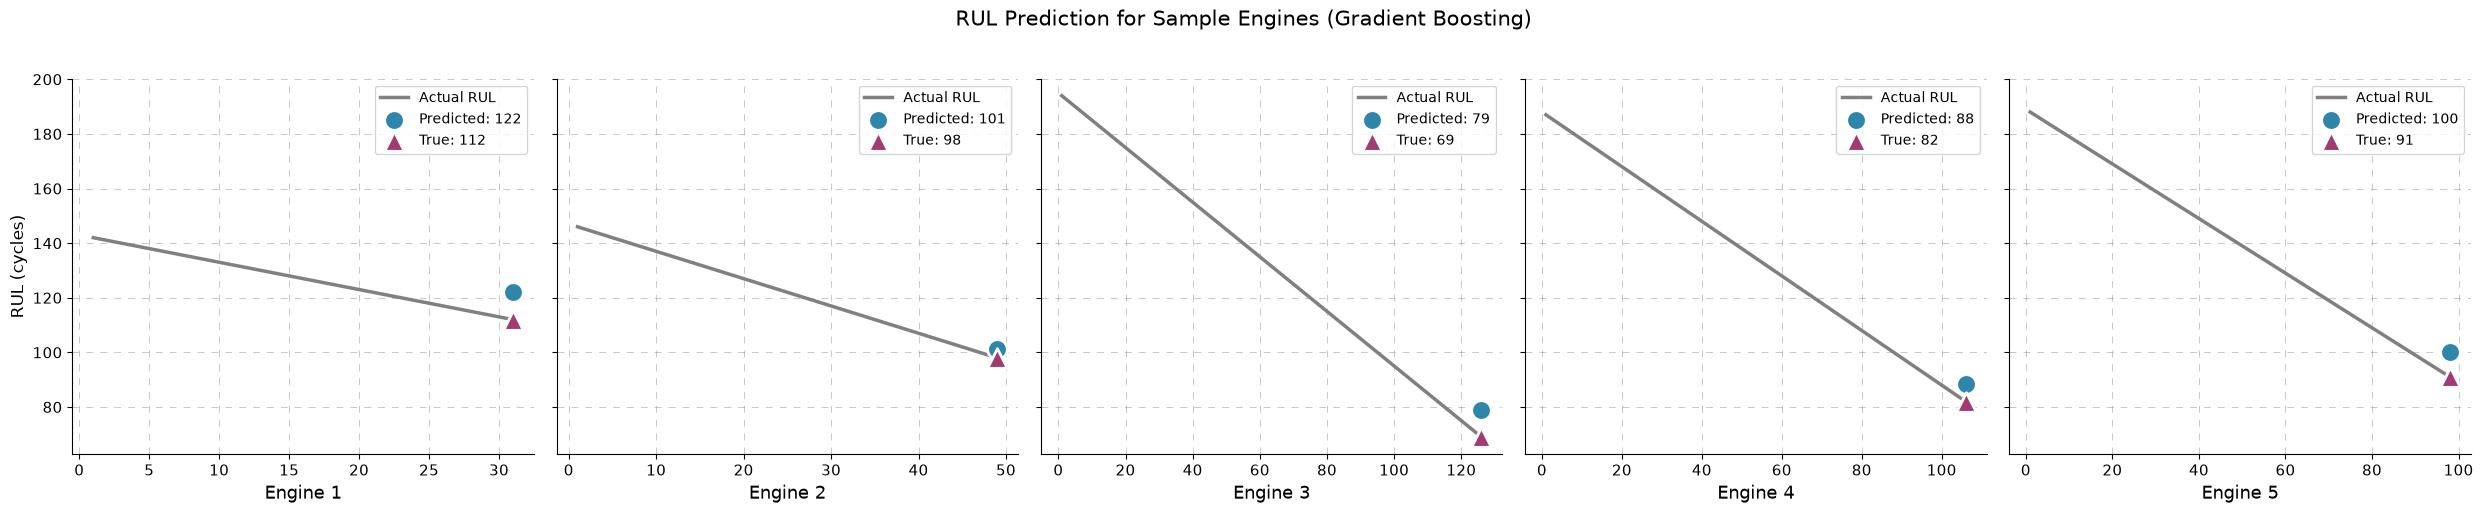

In [19]:
# RUL prediction over time for sample engines (using best model)
sample_engines = sorted(test_raw['unit_number'].unique())[:5]
y_pred_best = predictions[best_model_name]

fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)

for idx, eng_id in enumerate(sample_engines):
    ax = axes[idx]
    eng_data = test_raw[test_raw['unit_number'] == eng_id].sort_values('cycle')
    true_rul = y_test[eng_id - 1]  # RUL for this engine (1-indexed)
    
    # Plot actual RUL curve (linear decay from max_cycles to 0)
    max_cycle = eng_data['cycle'].max()
    cycles = eng_data['cycle'].values
    actual_rul_curve = max_cycle + true_rul - cycles
    ax.plot(cycles, actual_rul_curve, color='gray', linewidth=2.5, label='Actual RUL')
    
    # Plot predicted RUL at the last cycle
    pred_rul = y_pred_best[eng_id - 1]
    last_cycle = cycles[-1]
    ax.scatter([last_cycle], [pred_rul], color='#2E86AB', s=200, zorder=5, 
               edgecolors='white', linewidth=2, label=f'Predicted: {pred_rul:.0f}')
    ax.scatter([last_cycle], [true_rul], color='#A23B72', s=200, zorder=5,
               edgecolors='white', linewidth=2, marker='^', label=f'True: {true_rul:.0f}')
    
    ax.set_xlabel(f'Engine {eng_id}', fontsize=13)
    ax.set_ylabel('RUL (cycles)' if idx == 0 else '', fontsize=12)
    ax.legend(fontsize=10, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color='gray', linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.tick_params(labelsize=11)

plt.suptitle(f'RUL Prediction for Sample Engines ({best_model_name})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../assets/rul_prediction_sample_engines.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure:** RUL prediction for 5 sample test engines. The gray line shows the actual RUL declining over time. The blue dot is our model's prediction at the last available cycle, and the purple triangle is the true RUL. A good prediction places the blue dot close to the gray line.

## Save Model Artifact

We save the best-performing model so it can be reused in the Day 2 agentic AI demo. The saved file contains the trained model weights and configuration.

In [15]:
import joblib

# Save the best model and the scaler
best_model_obj = trained_models[best_model_name]
model_path = '../assets/models/rul_model.joblib'
best_rmse_val = comparison.iloc[0]['RMSE']
best_phm_val = comparison.iloc[0]['PHM Score']

joblib.dump({
    'model': best_model_obj,
    'scaler': scaler,
    'window_size': int(best_ws),
    'model_type': best_model_name,
    'rmse': float(best_rmse_val),
    'phm_score': float(best_phm_val)
}, model_path)

print(f"Model saved to {model_path}")
print(f"Model type: {best_model_name}")
print(f"Window size: {best_ws}")
print(f"Test RMSE: {best_rmse_val:.2f}")
print(f"Test PHM Score: {best_phm_val:.2f}")

# Verify the model can be loaded back
loaded = joblib.load(model_path)
print(f"\nVerification: model loaded successfully, type = {loaded['model_type']}")

Model saved to ../assets/models/rul_model.joblib
Model type: Gradient Boosting
Window size: 50
Test RMSE: 19.10
Test PHM Score: 630.70

Verification: model loaded successfully, type = Gradient Boosting


## Summary

We built a predictive maintenance pipeline for aircraft engine RUL prediction:

1. **Loaded** the NASA C-MAPSS FD001 dataset (100 training engines, 100 test engines).
2. **Explored** sensor trajectories to understand degradation patterns.
3. **Applied PCA** to visualize engine health clusters in 2 dimensions.
4. **Engineered features** using sliding window statistics (mean, std, min, max) with hyperparameter tuning for window size.
5. **Trained and compared** four regression models: Linear Regression, SVR, Gradient Boosting, and Random Forest.
6. **Evaluated** all models using RMSE and PHM Score on the test set.
7. **Saved** the best model for reuse in the Day 2 agentic AI demo.

The ensemble methods (Gradient Boosting and Random Forest) typically outperform simpler models on this task, demonstrating that machine learning can predict engine health from sensor data. This is the foundation of condition-based maintenance in modern aviation.

In [21]:
import gc

# Clean up large objects
del train_raw, test_raw, train_features
gc.collect()
print("Memory cleaned up.")

Memory cleaned up.
